In [1]:
import numpy as np
import random
import torch
# Define a fixed seed value
SEED = 42

# 1. Set the Python built-in random module's seed
random.seed(SEED)

# 2. Set the NumPy random seed
np.random.seed(SEED)

# 3. Set the PyTorch seed (for both CPU and GPU)
torch.manual_seed(SEED)# Define a fixed seed value
print(torch.cuda.is_available())

False


In [3]:
import scipy
from scipy.linalg import expm, sinm, cosm
import networkx as nx
from numpy import linalg as LA
from scipy import sparse
import matplotlib.pyplot as plt
import toponetx as tnx
from Util_functions import generate_complex, plot_complex, normalize_laplacian, laplacian_to_incidence

In [4]:
def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.maximum(alpha * x, x)

In [5]:
import time
start_time = time.time()

In [6]:
n = 10 # Number of nodes
p = 0.5 # probability
FF = 5 # Normalzing Factor
t_vec = [1e-6, 1e-2, 1e-1, 2e-1, 5e-1]
Layers = 100 # Maximum number of layers
max_gen = 50 # Number of random realziations
Fac = 5 # Normalizing Factor
FF_vec = 4 * np.ones((Layers+10,)) # Number of features

print(FF_vec)

[4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4.]


In [7]:
bound_actual = np.empty((Layers, max_gen, len(t_vec))) # For Discrete SNN
bound_theorem = np.empty((Layers, max_gen, len(t_vec))) # For Discrete SNN
bound_actual_COSIMO = np.empty((Layers, max_gen, len(t_vec))) # For COSIMO
bound_theorem_COSIMO = np.empty((Layers, max_gen, len(t_vec))) # For COSIMO

In [9]:
for gen in range(max_gen):
        
    sc = tnx.generators.linial_meshulam_complex(n, p) # Generating randm synthetic Simplicial Complexes
    
    B1 = sc.incidence_matrix(1).todense() # Obtaining incidence matrix B1
    B2 = sc.incidence_matrix(2).todense() # Obtaining incidence matrix B2
    #%%        
    
    L0 = sc.hodge_laplacian_matrix(0).todense() # Obtaining the node Hodge Laplcian L0
    L0 = normalize_laplacian(L0)
    N0 = L0.shape[0]
    L0_d = 0        #Lower node Hodge Laplacian
    L0_u = B1@B1.T  # Upper node Hodge Laplacian
    L0_u = normalize_laplacian(L0_u) 
    evals, evecs = LA.eig(L0_u) # Performing EVD on L0_u
    evals = evals.real
    lamb_min0_u = np.min(evals[np.where(evals>1e-3)]) #obtaing the minimum eigenvalue for L0_u 
    lamb_max0_u = np.max(evals) #obtaing the maximum eigenvalue for L0_u    
    
    L1 = sc.hodge_laplacian_matrix(1).todense() # Edge Hodge Laplacian
    L1 = normalize_laplacian(L1)
    N1 = L1.shape[0]
    L1_d = B1.T@B1 # Edge Lower Hodge Laplacian
    L1_d = normalize_laplacian(L1_d)
    evals, evecs = LA.eig(L1_d) # Performing EVD on L1_d
    evals = evals.real
    lamb_min1_d = np.min(evals[np.where(evals>1e-3)]) #obtaing the minimum eigenvalue for L1_d 
    lamb_max1_d = np.max(evals) #obtaing the maximum eigenvalue for L1_d    
    
    L1_u = B2@B2.T # Edge Upper Hodge Laplacian
    L1_u = normalize_laplacian(L1_u) 
    evals, evecs = LA.eig(L1_u) # Performing EVD on L1_u
    evals = evals.real
    lamb_min1_u = np.min(evals[np.where(evals>1e-3)]) #obtaing the minimum eigenvalue for L1_u
    lamb_max1_u = np.max(evals) #obtaing the maximum eigenvalue for L1_u 
    
    
    L2 = sc.hodge_laplacian_matrix(2).todense()  # Triangle Hodge Laplacian
    L2 = normalize_laplacian(L2)
    N2 = L2.shape[0]
    L2_d = B2.T@B2 # Triangle Lower Hodge Laplacian
    L2_d = normalize_laplacian(L2_d) 
    evals, evecs = LA.eig(L2_d) # Performing EVD on L2_d
    evals = evals.real
    lamb_min2_d = np.min(evals[np.where(evals>1e-3)]) #obtaing the minimum eigenvalue for L2_d
    lamb_max2_d = np.max(evals) #obtaing the maximum eigenvalue for L2_u
    L2_u = 0 # Triangle Upper Hodge Laplacian
        
    
    evals, evecs = LA.eig(L0) # Performing EVD on L0
    evals = evals.real
    lamb_min0 = np.min(evals[np.where(evals>1e-3)])
    lamb_max0 = np.max(evals)
    
    evals, evecs = LA.eig(L1) # Performing EVD on L1
    evals = evals.real
    lamb_min1 = np.min(evals[np.where(evals>1e-3)])
    lamb_max1 = np.max(evals)
    
    evals, evecs = LA.eig(L2) # Performing EVD on L2
    evals = evals.real
    lamb_min2 = np.min(evals[np.where(evals>1e-3)])
    lamb_max2 = np.max(evals)
    
    lamb_min = lamb_min1
    lamb_max = np.max([lamb_max0, lamb_max1, lamb_max2])
    
    #%% Generating random synthetic Simplicial Data on nodes, edges and trangles:
    FF = int(FF_vec[0])
    X0_l0 = np.random.randn(N0, FF)
    X0_l0 = X0_l0/LA.linalg.norm(X0_l0, ord=2)
    X1_l0 = np.random.randn(N1, FF)
    X1_l0 = X1_l0/LA.linalg.norm(X1_l0, ord=2)
    X2_l0 = np.random.randn(N2, FF)
    X2_l0 = X2_l0/LA.linalg.norm(X2_l0, ord=2)
    
    #%% Projections of the data on nodes, edges, and triangles:
    X0_l_u0 = B1@X1_l0
    X1_l_d0 = B1.T@X0_l0
    X1_l_u0 = B2@X2_l0
    X2_l_d0 = B2.T@X1_l0
    
    # N0 = N1 = N2 = int(FF_vec[1])
    
    #%% Generating the random weights:
    FF_l = int(FF_vec[0])
    FF_l2 = int(FF_vec[1])
    W0_u0 = np.random.randn(FF_l, FF_l2)
    W0_u0_2 = np.random.randn(FF_l, FF_l2)
    W0_u20 = np.random.randn(FF_l, FF_l2)
    W0_u20_2 = np.random.randn(FF_l, FF_l2)
    W1_d0 = np.random.randn(FF_l, FF_l2)
    W1_d0_2 = np.random.randn(FF_l, FF_l2)
    W1_d20 = np.random.randn(FF_l, FF_l2)
    W1_d20_2 = np.random.randn(FF_l, FF_l2)
    W1_u0 = np.random.randn(FF_l, FF_l2)
    W1_u0_2 = np.random.randn(FF_l, FF_l2)
    W1_u20 = np.random.randn(FF_l, FF_l2)
    W1_u20_2 = np.random.randn(FF_l, FF_l2)
    W2_d0 = np.random.randn(FF_l, FF_l2)
    W2_d0_2 = np.random.randn(FF_l, FF_l2)
    W2_d20 = np.random.randn(FF_l, FF_l2)
    W2_d20_2 = np.random.randn(FF_l, FF_l2)
    
    
    #%% Obtaining the maximum singular 
    s_max0 = np.max([LA.norm(W0_u0, ord=2)**2, LA.norm(W0_u20, ord=2)**2,
                    LA.norm(W1_d0, ord=2)**2, LA.norm(W1_d20, ord=2)**2, LA.norm(W1_u0, ord=2)**2, LA.norm(W1_u20, ord=2)**2,
                    LA.norm(W2_d0, ord=2)**2, LA.norm(W2_d20, ord=2)**2]) 
        
    # Fac = s_max0
    
    #%% Normalizing the random weights:
    W0_u0 = W0_u0/Fac
    W0_u20 = W0_u20/Fac
    W1_d0 = W1_d0/Fac
    W1_d20 = W1_d20/Fac
    W1_u0 = W1_u0/Fac
    W1_u20 = W1_u20/Fac
    W2_d0 = W2_d0/Fac
    W2_d20 = W2_d20/Fac


    for i, t in enumerate(t_vec):
    
        t_d = t_d2 = t_u = t_u2 = t; 
        Phi = np.min([t_d*lamb_min1_d, t_u*lamb_min1_u]) # obtaining \Phi in the paper
        Phi2 = np.min([t_d2*lamb_min1_d, t_u2*lamb_min1_u]) # obtaining \Phi in the paper
        s_max = s_max0
        
        X0_l = X0_l0
        X1_l = X1_l0
        X2_l = X2_l0
        X0_l_u = X0_l_u0
        X1_l_d = X1_l_d0
        X1_l_u = X1_l_u0
        X2_l_d = X2_l_d0
        
        X0_l_COSIMO = X0_l0
        X1_l_COSIMO = X1_l0
        X2_l_COSIMO = X2_l0
        X0_l_u_COSIMO = X0_l_u0
        X1_l_d_COSIMO = X1_l_d0
        X1_l_u_COSIMO = X1_l_u0
        X2_l_d_COSIMO = X2_l_d0


        W0_u = W0_u0
        W0_u_2 = W0_u0_2
        W0_u2 = W0_u20
        W0_u2_2 = W0_u20_2
        W1_d = W1_d0
        W1_d_2 = W1_d0_2
        W1_d2 = W1_d20
        W1_d2_2 = W1_d20_2
        W1_u = W1_u0
        W1_u_2 = W1_u0_2
        W1_u2 = W1_u20
        W1_u2_2 = W1_u20_2
        W2_d = W2_d0
        W2_d_2 = W2_d0_2
        W2_d2 = W2_d20
        W2_d2_2 = W2_d20_2
    
    
        for l in range(Layers):
            X0_l_plus = leaky_relu(L0_u@X0_l@W0_u + L0_u@X0_l_u@W0_u2)            
            X1_l_plus = leaky_relu(L1_d@X1_l_d@W1_d2 + L1_d@X1_l@W1_d + L1_u@X1_l@W1_u + L1_u@X1_l_u@W1_u2)
            X2_l_plus = leaky_relu(L2_d@X2_l@W2_d + L2_d@X2_l_d@W2_d2)
        
            term1 = np.trace(X1_l.T @ L1 @ X1_l) * np.power(lamb_max, 2) * s_max
            term2 = (np.trace(X0_l.T @ L0 @ X0_l) + np.trace(X2_l.T @ L2 @ X2_l)) * (lamb_max**3) * s_max
            term3 = 2 * FF_vec[0] * LA.norm(X1_l, ord=2) * (LA.norm(X0_l, ord=2) + LA.norm(X2_l, ord=2)) * np.power(lamb_max, 3.5) * s_max
        
            E_l = np.trace(X1_l.T @ (L1) @ X1_l)
            E_l_plus = np.trace(X1_l_plus.T @ (L1) @ X1_l_plus)
            bound_actual[l, gen, i] = E_l_plus
            bound_theorem[l, gen, i] = term1 + term2 + term3
    
    
            X0_l_plus_COSIMO = leaky_relu(expm(-t_u*L0_u)@X0_l_COSIMO@W0_u + expm(-t_u2*L0_u)@X0_l_u_COSIMO@W0_u2)
            X1_l_plus_COSIMO = leaky_relu(expm(-t_d2*L1_d)@X1_l_d_COSIMO@W1_d2 + expm(-t_d*L1_d)@X1_l_COSIMO@W1_d + expm(-t_u*L1_u)@X1_l_COSIMO@W1_u + expm(-t_u2*L1_u)@X1_l_u_COSIMO@W1_u2)
            X2_l_plus_COSIMO = leaky_relu(expm(-t_d*L2_d)@X2_l_COSIMO@W2_d + expm(-t_d2*L2_d)@X2_l_d_COSIMO@W2_d2)
        
            term1_COSIMO = np.trace(X1_l_COSIMO.T @ L1 @ X1_l_COSIMO) * (np.exp(-2 * Phi) + 1) * s_max # term 1
            term2_COSIMO = np.exp(-2 * Phi2) * (np.trace(X0_l_COSIMO.T @ L0 @ X0_l_COSIMO) + np.trace(X2_l_COSIMO.T @ L2 @ X2_l_COSIMO)) * (lamb_max) * s_max # term 2
            term3_COSIMO = 2 * FF_vec[0] * (np.exp(-Phi2) + np.exp(-2 * Phi2)) * LA.norm(X1_l_COSIMO, ord=2) * (LA.norm(X0_l_COSIMO, ord=2) + LA.norm(X2_l_COSIMO, ord=2)) * np.power(lamb_max, 1.5) * s_max # term 3
            term4_COSIMO = 2 * FF_vec[0] * np.exp(-Phi2) * (LA.norm(X1_l_COSIMO, ord=2)**2) * lamb_max * s_max # term 4
        
            E_l_COSIMO = np.trace(X1_l_COSIMO.T @ (L1) @ X1_l_COSIMO)
            E_l_plus_COSIMO = np.trace(X1_l_plus_COSIMO.T @ L1 @ X1_l_plus_COSIMO)
            bound_actual_COSIMO[l, gen, i] = E_l_plus_COSIMO
            bound_theorem_COSIMO[l, gen, i] = term1_COSIMO + term2_COSIMO + term3_COSIMO + term4_COSIMO
            # bound_theorem_COSIMO[l, gen, i] = 10

        
            X0_l = X0_l_plus
            X1_l = X1_l_plus
            X2_l = X2_l_plus
            X0_l_u = B1@X1_l
            X1_l_d = B1.T@X0_l
            X1_l_u = B2@X2_l
            X2_l_d = B2.T@X1_l
            
            X0_l_COSIMO = X0_l_plus_COSIMO
            X1_l_COSIMO = X1_l_plus_COSIMO
            X2_l_COSIMO = X2_l_plus_COSIMO
            X0_l_u_COSIMO = B1@X1_l_COSIMO
            X1_l_d_COSIMO = B1.T@X0_l_COSIMO
            X1_l_u_COSIMO = B2@X2_l_COSIMO
            X2_l_d_COSIMO = B2.T@X1_l_COSIMO



            FF = int(FF_vec[l+1])
            FF_l2 = int(FF_vec[l+2])
            
            s_max = np.max([s_max, LA.norm(W0_u, ord=2)**2, LA.norm(W0_u2, ord=2)**2,
                            LA.norm(W1_d, ord=2)**2, LA.norm(W1_d2, ord=2)**2, LA.norm(W1_u, ord=2)**2, LA.norm(W1_u2, ord=2)**2,
                            LA.norm(W2_d, ord=2)**2, LA.norm(W2_d2, ord=2)**2])

            W0_u = np.random.randn(X0_l.shape[1], FF_l2)/Fac
            W0_u_2 = np.random.randn(X0_l.shape[1], FF_l2)/Fac
            W0_u2 = np.random.randn(X0_l_u.shape[1], FF_l2)/Fac
            W0_u2_2 = np.random.randn(X0_l_u.shape[1], FF_l2)/Fac
            
            W1_d2 = np.random.randn(X1_l_d.shape[1], FF_l2)/Fac
            W1_d2_2 = np.random.randn(X1_l_d.shape[1], FF_l2)/Fac
            W1_d = np.random.randn(X1_l.shape[1], FF_l2)/Fac
            W1_d_2 = np.random.randn(X1_l.shape[1], FF_l2)/Fac
            W1_u = np.random.randn(X1_l.shape[1], FF_l2)/Fac
            W1_u_2 = np.random.randn(X1_l.shape[1], FF_l2)/Fac
            W1_u2 = np.random.randn(X1_l_u.shape[1], FF_l2)/Fac
            W1_u2_2 = np.random.randn(X1_l_u.shape[1], FF_l2)/Fac
            
            W2_d = np.random.randn(X2_l.shape[1], FF_l2)/Fac
            W2_d_2 = np.random.randn(X2_l.shape[1], FF_l2)/Fac
            W2_d2 = np.random.randn(X2_l_d.shape[1], FF_l2)/Fac
            W2_d2_2 = np.random.randn(X2_l_d.shape[1], FF_l2)/Fac

KeyboardInterrupt: 

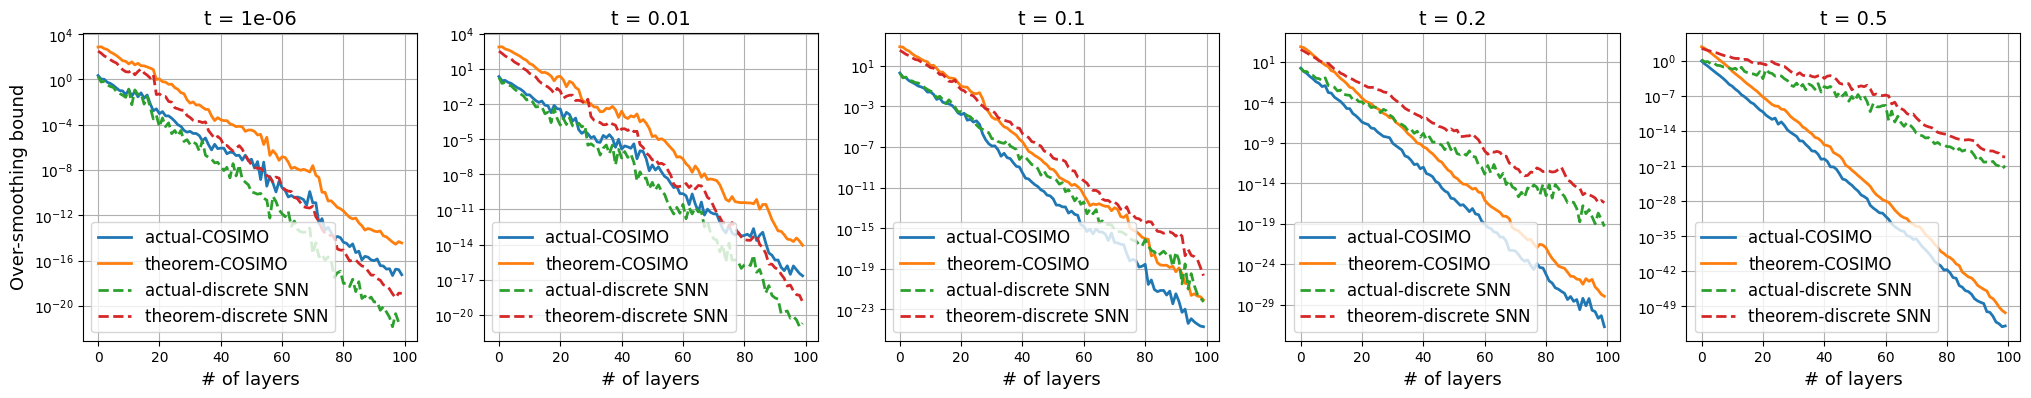

In [8]:
plt.figure(figsize=(25,4))
for i in range(len(t_vec)):
    
    # Compute mean and standard deviation at each time point
    mean_actual = np.mean(bound_actual[:, :, i], axis=1)
    std_dev_actual = np.std(bound_actual[:, :, i], axis=1)
    
    mean_theorem = np.mean(bound_theorem[:, :, i], axis=1)
    std_dev_theorem = np.std(bound_theorem[:, :, i], axis=1)


    mean_actual_COSIMO = np.mean(bound_actual_COSIMO[:, :, i], axis=1)
    std_dev_actual_COSIMO = np.std(bound_actual_COSIMO[:, :, i], axis=1)
    
    mean_theorem_COSIMO = np.mean(bound_theorem_COSIMO[:, :, i], axis=1)
    std_dev_theorem_COSIMO = np.std(bound_theorem_COSIMO[:, :, i], axis=1)

    # Create the plot:

    
    plt.subplot(1, len(t_vec), i+1)  # 2 rows, 2 columns, position 1
    
    # Plot the mean    
    plt.plot(np.arange(Layers), mean_actual_COSIMO, label='actual-COSIMO', linewidth=2)    
    
    plt.plot(np.arange(Layers), mean_theorem_COSIMO, label='theorem-COSIMO', linewidth=2)

    plt.plot(np.arange(Layers), mean_actual, label='actual-discrete SNN', linestyle='--', linewidth=2)    
    
    plt.plot(np.arange(Layers), mean_theorem, label='theorem-discrete SNN', linestyle='--', linewidth=2)

    # Add labels and title
    plt.yscale('log')
    plt.xlabel('# of layers', fontsize=13)
    if i == 0:
        plt.ylabel('Over-smoothing bound', fontsize=13)
    plt.title('t = ' + str(t_vec[i]), fontsize=14)# + ', upper_bound: ' + str(round(np.mean(upper_bound), 2)), fontsize=15)
    plt.grid(True)
    plt.legend(fontsize=12)
    

In [9]:
finish_time = time.time()
print("--- %s minutes ---" % (round((finish_time - start_time)/60, 2)))

--- 0.93 minutes ---
